In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/yazanibrahimalghamdi/all-datasets-for-gp/All Datasets For GP/Tik Tok Datasets - After Processing/المنطقة الوسطى/Tik Data/القصيم/dataset_tiktok-comments-scraper_2025-11-05_23-34-09-183_textready_analysis.xlsx
/kaggle/input/datasets/yazanibrahimalghamdi/all-datasets-for-gp/All Datasets For GP/Tik Tok Datasets - After Processing/المنطقة الوسطى/Tik Data/القصيم/dataset_tiktok-comments-scraper_2025-11-05_23-06-43-625_textready_analysis.xlsx
/kaggle/input/datasets/yazanibrahimalghamdi/all-datasets-for-gp/All Datasets For GP/Tik Tok Datasets - After Processing/المنطقة الوسطى/Tik Data/القصيم/dataset_tiktok-comments-scraper_2025-11-05_23-17-06-320_textready_cleaned.xlsx
/kaggle/input/datasets/yazanibrahimalghamdi/all-datasets-for-gp/All Datasets For GP/Tik Tok Datasets - After Processing/المنطقة الوسطى/Tik Data/القصيم/dataset_tiktok-comments-scraper_2025-11-05_23-37-52-643_textready_analysis.xlsx
/kaggle/input/datasets/yazanibrahimalghamdi/all-datasets-for-gp/All Datasets 

✅ Files used    : 935
⚠️ Files skipped : 1
📊 Raw records   : 1188384
📊 Records used for modeling: 1188100

📌 Class distribution:
sentiment
positive    872505
neutral     170601
negative    144994
Name: count, dtype: int64

📌 Source distribution:
source
google_maps    1016215
tiktok          113710
youtube          58175
Name: count, dtype: int64

Train size: 950480
Test size : 237620

🚀 Training Linear SVM on Text_ML only ...

📊 LINEAR SVM RESULTS
Accuracy    : 0.8044
Macro F1    : 0.6395
Weighted F1 : 0.7921

📋 Classification Report:

              precision    recall  f1-score   support

    negative       0.63      0.50      0.56     28999
     neutral       0.55      0.40      0.47     34120
    positive       0.86      0.93      0.89    174501

    accuracy                           0.80    237620
   macro avg       0.68      0.61      0.64    237620
weighted avg       0.79      0.80      0.79    237620

📌 Confusion Matrix:

[[ 14613   3893  10493]
 [  4339  13738  16043]
 [  4372

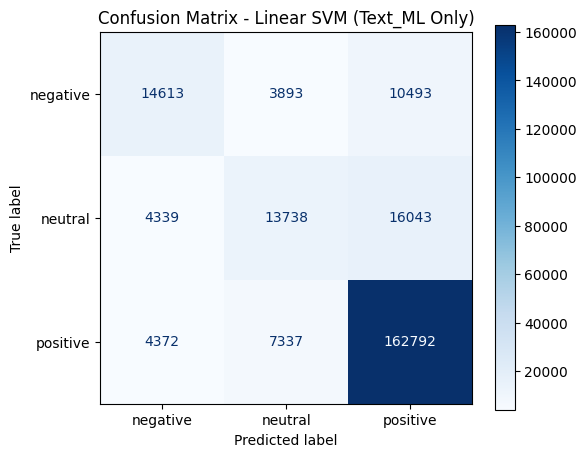


📁 Files saved in: ./linear_svm_text_ml_results
- merged_all_sources_text_ml.csv
- test_predictions_text_ml.csv

⚠️ Sample skipped files:
- /kaggle/input/datasets/yazanibrahimalghamdi/all-datasets-for-gp/All Datasets For GP/Cleaned Data From Google Maps/( المنطقة الجنوبية ) Google Maps Data -  After Cleaning/منطقة جازان/جبال فيفاء_textready.xlsx => Missing Text_ML or sentiment columns


In [2]:
# =========================================================
# 1) IMPORTS
# =========================================================
import os
import warnings
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    f1_score
)

warnings.filterwarnings("ignore")

# =========================================================
# 2) SETTINGS
# =========================================================
FOLDER_PATH = r"/kaggle/input/datasets/yazanibrahimalghamdi/all-datasets-for-gp/All Datasets For GP"

RANDOM_STATE = 42
TEST_SIZE = 0.20
VALID_LABELS = ["negative", "neutral", "positive"]

# =========================================================
# 3) HELPERS
# =========================================================
def normalize_sentiment(label):
    if pd.isna(label):
        return None

    x = str(label).strip().lower()

    mapping = {
        "negative": "negative",
        "neg": "negative",
        "سلبي": "negative",

        "neutral": "neutral",
        "neu": "neutral",
        "محايد": "neutral",

        "positive": "positive",
        "pos": "positive",
        "ايجابي": "positive",
        "إيجابي": "positive"
    }

    return mapping.get(x, None)


def stars_to_sentiment(star):
    try:
        s = float(star)
    except:
        return None

    if s <= 2:
        return "negative"
    elif s == 3:
        return "neutral"
    elif s >= 4:
        return "positive"
    return None


def read_file(file_path):
    ext = os.path.splitext(file_path)[1].lower()

    if ext == ".csv":
        for enc in ["utf-8-sig", "utf-8", "cp1256", "latin1"]:
            try:
                return pd.read_csv(file_path, encoding=enc)
            except:
                continue
        raise ValueError(f"Could not read CSV: {file_path}")

    elif ext in [".xlsx", ".xls"]:
        return pd.read_excel(file_path)

    return None


def infer_source(file_path):
    p = file_path.lower()

    if "tik tok" in p or "tiktok" in p:
        return "tiktok"
    elif "youtube" in p:
        return "youtube"
    elif "google maps" in p or "maps" in p:
        return "google_maps"
    else:
        return "unknown"


def should_use_file(file_path):
    """
    TikTok / YouTube: cleaned فقط
    Google Maps: كل الملفات الموجودة في المجلد المنظف
    """
    p = file_path.lower()
    source = infer_source(file_path)

    if source in ["tiktok", "youtube"]:
        return ("cleaned" in p) and p.endswith((".xlsx", ".xls", ".csv"))

    if source == "google_maps":
        return p.endswith((".xlsx", ".xls", ".csv"))

    return False


def build_standard_df(df, file_path):
    source = infer_source(file_path)

    # نعتمد فقط على Text_ML
    if "Text_ML" not in df.columns:
        return None

    temp = pd.DataFrame()
    temp["text"] = df["Text_ML"]

    # TikTok / YouTube
    if source in ["tiktok", "youtube"]:
        if "Sentiment" in df.columns:
            temp["sentiment"] = df["Sentiment"].apply(normalize_sentiment)
        elif "sentiment" in df.columns:
            temp["sentiment"] = df["sentiment"].apply(normalize_sentiment)
        elif "Stars" in df.columns:
            temp["sentiment"] = df["Stars"].apply(stars_to_sentiment)
        elif "stars" in df.columns:
            temp["sentiment"] = df["stars"].apply(stars_to_sentiment)
        else:
            return None

    # Google Maps
    elif source == "google_maps":
        if "stars" in df.columns:
            temp["sentiment"] = df["stars"].apply(stars_to_sentiment)
        elif "Stars" in df.columns:
            temp["sentiment"] = df["Stars"].apply(stars_to_sentiment)
        elif "Sentiment" in df.columns:
            temp["sentiment"] = df["Sentiment"].apply(normalize_sentiment)
        elif "sentiment" in df.columns:
            temp["sentiment"] = df["sentiment"].apply(normalize_sentiment)
        else:
            return None
    else:
        return None

    temp["source"] = source
    temp["file_name"] = os.path.basename(file_path)
    temp["file_path"] = file_path

    return temp


# =========================================================
# 4) LOAD DATA
# =========================================================
all_frames = []
used_files = []
skipped_files = []

for root, dirs, files in os.walk(FOLDER_PATH):
    for file in files:
        if not file.lower().endswith((".xlsx", ".xls", ".csv")):
            continue

        file_path = os.path.join(root, file)

        if not should_use_file(file_path):
            continue

        try:
            df = read_file(file_path)

            if df is None or df.empty:
                skipped_files.append((file_path, "Empty or unreadable"))
                continue

            std_df = build_standard_df(df, file_path)

            if std_df is None:
                skipped_files.append((file_path, "Missing Text_ML or sentiment columns"))
                continue

            all_frames.append(std_df)
            used_files.append(file_path)

        except Exception as e:
            skipped_files.append((file_path, str(e)))

if not all_frames:
    raise ValueError("لم يتم العثور على ملفات صالحة. تأكد من المسار وبنية البيانات.")

data = pd.concat(all_frames, ignore_index=True)

print("=" * 70)
print("✅ Files used    :", len(used_files))
print("⚠️ Files skipped :", len(skipped_files))
print("📊 Raw records   :", len(data))
print("=" * 70)

# =========================================================
# 5) KEEP DATA AS-IS
# =========================================================
# لا تنظيف نصي
# لا حذف تكرارات
# لا معالجة إضافية
# فقط حذف السجلات التي لا تحتوي على النص أو التصنيف

data = data.dropna(subset=["text", "sentiment"])
data = data[data["sentiment"].isin(VALID_LABELS)]

print("📊 Records used for modeling:", len(data))

print("\n📌 Class distribution:")
print(data["sentiment"].value_counts())

print("\n📌 Source distribution:")
print(data["source"].value_counts())

# =========================================================
# 6) TRAIN / TEST SPLIT
# =========================================================
X = data["text"].astype(str)
y = data["sentiment"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

print("\nTrain size:", len(X_train))
print("Test size :", len(X_test))

# =========================================================
# 7) PIPELINE: TF-IDF + Linear SVM
# =========================================================
pipeline = Pipeline([
    ("features", FeatureUnion([
        ("word_tfidf", TfidfVectorizer(
            analyzer="word",
            ngram_range=(1, 2),
            max_features=25000,
            min_df=2,
            max_df=0.95,
            sublinear_tf=True
        )),
        ("char_tfidf", TfidfVectorizer(
            analyzer="char_wb",
            ngram_range=(3, 5),
            min_df=2,
            max_df=0.95,
            sublinear_tf=True
        ))
    ])),
    ("clf", LinearSVC(
        class_weight="balanced",
        random_state=RANDOM_STATE
    ))
])

# =========================================================
# 8) TRAIN
# =========================================================
print("\n🚀 Training Linear SVM on Text_ML only ...")
pipeline.fit(X_train, y_train)

# =========================================================
# 9) EVALUATION
# =========================================================
y_pred = pipeline.predict(X_test)

acc = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average="macro")
weighted_f1 = f1_score(y_test, y_pred, average="weighted")

print("\n" + "=" * 70)
print("📊 LINEAR SVM RESULTS")
print("=" * 70)
print(f"Accuracy    : {acc:.4f}")
print(f"Macro F1    : {macro_f1:.4f}")
print(f"Weighted F1 : {weighted_f1:.4f}")

print("\n📋 Classification Report:\n")
print(classification_report(y_test, y_pred, labels=VALID_LABELS))

# =========================================================
# 10) CONFUSION MATRIX
# =========================================================
cm = confusion_matrix(y_test, y_pred, labels=VALID_LABELS)

print("📌 Confusion Matrix:\n")
print(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=VALID_LABELS)
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap="Blues", values_format="d")
plt.title("Confusion Matrix - Linear SVM (Text_ML Only)")
plt.show()

# =========================================================
# 11) SAVE OUTPUTS
# =========================================================
output_dir = "./linear_svm_text_ml_results"
os.makedirs(output_dir, exist_ok=True)

data.to_csv(
    os.path.join(output_dir, "merged_all_sources_text_ml.csv"),
    index=False,
    encoding="utf-8-sig"
)

pred_df = pd.DataFrame({
    "text": X_test.values,
    "true_sentiment": y_test.values,
    "predicted_sentiment": y_pred
})

pred_df.to_csv(
    os.path.join(output_dir, "test_predictions_text_ml.csv"),
    index=False,
    encoding="utf-8-sig"
)

print("\n📁 Files saved in:", output_dir)
print("- merged_all_sources_text_ml.csv")
print("- test_predictions_text_ml.csv")

# =========================================================
# 12) SHOW SKIPPED FILES SAMPLE
# =========================================================
if skipped_files:
    print("\n⚠️ Sample skipped files:")
    for fp, reason in skipped_files[:15]:
        print("-", fp, "=>", reason)

In [3]:
# =========================================================
# SAVE MODEL
# =========================================================
import joblib
import os

model_path = "./saved_models"
os.makedirs(model_path, exist_ok=True)

# حفظ الـ Pipeline كامل (vectorizer + model)
joblib.dump(pipeline, os.path.join(model_path, "linear_svm_text_ml_model.pkl"))

print("✅ Model saved successfully!")
print("📁 Path:", os.path.join(model_path, "linear_svm_text_ml_model.pkl"))

✅ Model saved successfully!
📁 Path: ./saved_models/linear_svm_text_ml_model.pkl


Records used for binary classification: 1017499
sentiment
positive    872505
negative    144994
Name: count, dtype: int64
Training binary Linear SVM ...

Accuracy: 0.9028
Binary F1: 0.9437

Classification Report:

              precision    recall  f1-score   support

    negative       0.67      0.62      0.65     28999
    positive       0.94      0.95      0.94    174501

    accuracy                           0.90    203500
   macro avg       0.80      0.79      0.79    203500
weighted avg       0.90      0.90      0.90    203500

Confusion Matrix:
 [[ 18011  10988]
 [  8801 165700]]


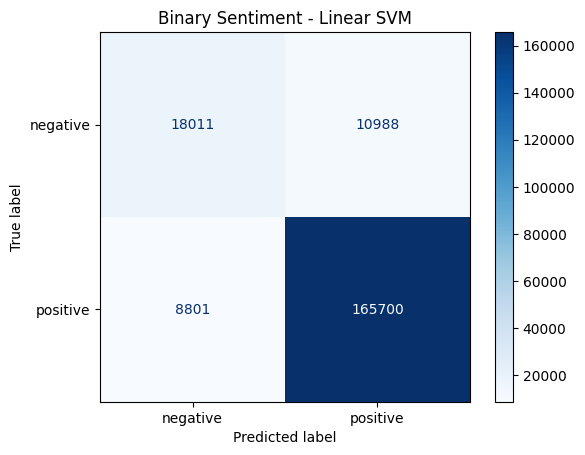

Model saved: ./saved_models/linear_svm_binary_text_ml.pkl


In [5]:
import os
import warnings
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    f1_score
)

warnings.filterwarnings("ignore")

FOLDER_PATH = r"/kaggle/input/datasets/yazanibrahimalghamdi/all-datasets-for-gp/All Datasets For GP"
RANDOM_STATE = 42
TEST_SIZE = 0.20
VALID_LABELS = ["negative", "positive"]


def normalize_sentiment_binary(label):
    if pd.isna(label):
        return None

    x = str(label).strip().lower()

    mapping = {
        "negative": "negative",
        "neg": "negative",
        "سلبي": "negative",

        "positive": "positive",
        "pos": "positive",
        "ايجابي": "positive",
        "إيجابي": "positive"
    }

    return mapping.get(x, None)


def stars_to_binary_sentiment(star):
    try:
        s = float(star)
    except:
        return None

    if s <= 2:
        return "negative"
    elif s >= 4:
        return "positive"
    else:
        return None


def read_file(file_path):
    ext = os.path.splitext(file_path)[1].lower()

    if ext == ".csv":
        for enc in ["utf-8-sig", "utf-8", "cp1256", "latin1"]:
            try:
                return pd.read_csv(file_path, encoding=enc)
            except:
                continue
        raise ValueError(f"Could not read CSV: {file_path}")

    elif ext in [".xlsx", ".xls"]:
        return pd.read_excel(file_path)

    return None


def infer_source(file_path):
    p = file_path.lower()

    if "tik tok" in p or "tiktok" in p:
        return "tiktok"
    elif "youtube" in p:
        return "youtube"
    elif "google maps" in p or "maps" in p:
        return "google_maps"
    else:
        return "unknown"


def should_use_file(file_path):
    p = file_path.lower()
    source = infer_source(file_path)

    if source in ["tiktok", "youtube"]:
        return ("cleaned" in p) and p.endswith((".xlsx", ".xls", ".csv"))

    if source == "google_maps":
        return p.endswith((".xlsx", ".xls", ".csv"))

    return False


def build_standard_df(df, file_path):
    source = infer_source(file_path)

    if "Text_ML" not in df.columns:
        return None

    temp = pd.DataFrame()
    temp["text"] = df["Text_ML"]

    if source in ["tiktok", "youtube"]:
        if "Sentiment" in df.columns:
            temp["sentiment"] = df["Sentiment"].apply(normalize_sentiment_binary)
        elif "sentiment" in df.columns:
            temp["sentiment"] = df["sentiment"].apply(normalize_sentiment_binary)
        elif "Stars" in df.columns:
            temp["sentiment"] = df["Stars"].apply(stars_to_binary_sentiment)
        elif "stars" in df.columns:
            temp["sentiment"] = df["stars"].apply(stars_to_binary_sentiment)
        else:
            return None

    elif source == "google_maps":
        if "stars" in df.columns:
            temp["sentiment"] = df["stars"].apply(stars_to_binary_sentiment)
        elif "Stars" in df.columns:
            temp["sentiment"] = df["Stars"].apply(stars_to_binary_sentiment)
        elif "Sentiment" in df.columns:
            temp["sentiment"] = df["Sentiment"].apply(normalize_sentiment_binary)
        elif "sentiment" in df.columns:
            temp["sentiment"] = df["sentiment"].apply(normalize_sentiment_binary)
        else:
            return None
    else:
        return None

    temp["source"] = source
    temp["file_name"] = os.path.basename(file_path)
    return temp


all_frames = []

for root, dirs, files in os.walk(FOLDER_PATH):
    for file in files:
        if not file.lower().endswith((".xlsx", ".xls", ".csv")):
            continue

        file_path = os.path.join(root, file)

        if not should_use_file(file_path):
            continue

        try:
            df = read_file(file_path)
            if df is None or df.empty:
                continue

            std_df = build_standard_df(df, file_path)
            if std_df is not None:
                all_frames.append(std_df)

        except:
            pass

data = pd.concat(all_frames, ignore_index=True)

# نحتفظ فقط بإيجابي/سلبي
data = data.dropna(subset=["text", "sentiment"])
data = data[data["sentiment"].isin(["negative", "positive"])]

print("Records used for binary classification:", len(data))
print(data["sentiment"].value_counts())

X = data["text"].astype(str)
y = data["sentiment"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

pipeline = Pipeline([
    ("features", FeatureUnion([
        ("word_tfidf", TfidfVectorizer(
            analyzer="word",
            ngram_range=(1, 2),
            max_features=25000,
            min_df=2,
            max_df=0.95,
            sublinear_tf=True
        )),
        ("char_tfidf", TfidfVectorizer(
            analyzer="char_wb",
            ngram_range=(3, 5),
            min_df=2,
            max_df=0.95,
            sublinear_tf=True
        ))
    ])),
    ("clf", LinearSVC(
        class_weight="balanced",
        random_state=RANDOM_STATE
    ))
])

print("Training binary Linear SVM ...")
pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average="binary", pos_label="positive")

print("\nAccuracy:", round(acc, 4))
print("Binary F1:", round(f1, 4))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, labels=VALID_LABELS))

cm = confusion_matrix(y_test, y_pred, labels=VALID_LABELS)
print("Confusion Matrix:\n", cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=VALID_LABELS)
disp.plot(cmap="Blues", values_format="d")
plt.title("Binary Sentiment - Linear SVM")
plt.show()

# حفظ المودل
os.makedirs("./saved_models", exist_ok=True)
joblib.dump(pipeline, "./saved_models/linear_svm_binary_text_ml.pkl")
print("Model saved: ./saved_models/linear_svm_binary_text_ml.pkl")

Records used for binary classification: 1017499
sentiment
positive    872505
negative    144994
Name: count, dtype: int64
Training binary Linear SVM ...

Accuracy: 0.9052
Binary F1 (positive): 0.9452
Binary F1 (negative): 0.6459
Macro F1: 0.7956

Classification Report:

              precision    recall  f1-score   support

    negative       0.69      0.61      0.65     28999
    positive       0.94      0.95      0.95    174501

    accuracy                           0.91    203500
   macro avg       0.81      0.78      0.80    203500
weighted avg       0.90      0.91      0.90    203500

Confusion Matrix:
 [[ 17599  11400]
 [  7900 166601]]


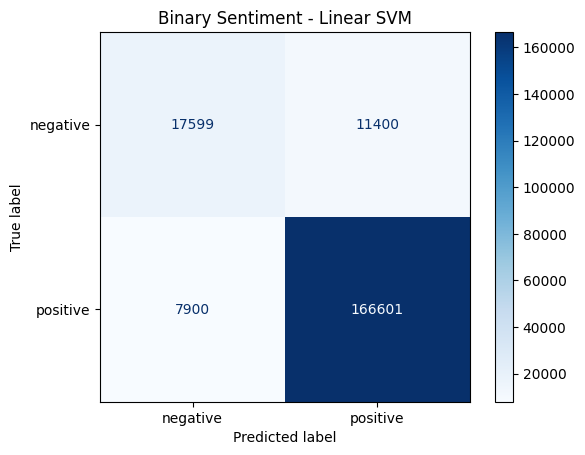

Model saved: ./saved_models/linear_svm_binary_text_ml.pkl


In [1]:
import os
import warnings
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    f1_score
)

warnings.filterwarnings("ignore")

FOLDER_PATH = r"/kaggle/input/datasets/yazanibrahimalghamdi/all-datasets-for-gp/All Datasets For GP"
RANDOM_STATE = 42
TEST_SIZE = 0.20
VALID_LABELS = ["negative", "positive"]


def normalize_sentiment_binary(label):
    if pd.isna(label):
        return None

    x = str(label).strip().lower()

    mapping = {
        "negative": "negative",
        "neg": "negative",
        "سلبي": "negative",

        "positive": "positive",
        "pos": "positive",
        "ايجابي": "positive",
        "إيجابي": "positive"
    }

    return mapping.get(x, None)


def stars_to_binary_sentiment(star):
    try:
        s = float(star)
    except:
        return None

    if s <= 2:
        return "negative"
    elif s >= 4:
        return "positive"
    else:
        return None


def read_file(file_path):
    ext = os.path.splitext(file_path)[1].lower()

    if ext == ".csv":
        for enc in ["utf-8-sig", "utf-8", "cp1256", "latin1"]:
            try:
                return pd.read_csv(file_path, encoding=enc)
            except:
                continue
        raise ValueError(f"Could not read CSV: {file_path}")

    elif ext in [".xlsx", ".xls"]:
        return pd.read_excel(file_path)

    return None


def infer_source(file_path):
    p = file_path.lower()

    if "tik tok" in p or "tiktok" in p:
        return "tiktok"
    elif "youtube" in p:
        return "youtube"
    elif "google maps" in p or "maps" in p:
        return "google_maps"
    else:
        return "unknown"


def should_use_file(file_path):
    p = file_path.lower()
    source = infer_source(file_path)

    if source in ["tiktok", "youtube"]:
        return ("cleaned" in p) and p.endswith((".xlsx", ".xls", ".csv"))

    if source == "google_maps":
        return p.endswith((".xlsx", ".xls", ".csv"))

    return False


def build_standard_df(df, file_path):
    source = infer_source(file_path)

    if "Text_ML" not in df.columns:
        return None

    temp = pd.DataFrame()
    temp["text"] = df["Text_ML"]

    if source in ["tiktok", "youtube"]:
        if "Sentiment" in df.columns:
            temp["sentiment"] = df["Sentiment"].apply(normalize_sentiment_binary)
        elif "sentiment" in df.columns:
            temp["sentiment"] = df["sentiment"].apply(normalize_sentiment_binary)
        elif "Stars" in df.columns:
            temp["sentiment"] = df["Stars"].apply(stars_to_binary_sentiment)
        elif "stars" in df.columns:
            temp["sentiment"] = df["stars"].apply(stars_to_binary_sentiment)
        else:
            return None

    elif source == "google_maps":
        if "stars" in df.columns:
            temp["sentiment"] = df["stars"].apply(stars_to_binary_sentiment)
        elif "Stars" in df.columns:
            temp["sentiment"] = df["Stars"].apply(stars_to_binary_sentiment)
        elif "Sentiment" in df.columns:
            temp["sentiment"] = df["Sentiment"].apply(normalize_sentiment_binary)
        elif "sentiment" in df.columns:
            temp["sentiment"] = df["sentiment"].apply(normalize_sentiment_binary)
        else:
            return None
    else:
        return None

    temp["source"] = source
    temp["file_name"] = os.path.basename(file_path)
    return temp


all_frames = []

for root, dirs, files in os.walk(FOLDER_PATH):
    for file in files:
        if not file.lower().endswith((".xlsx", ".xls", ".csv")):
            continue

        file_path = os.path.join(root, file)

        if not should_use_file(file_path):
            continue

        try:
            df = read_file(file_path)
            if df is None or df.empty:
                continue

            std_df = build_standard_df(df, file_path)
            if std_df is not None:
                all_frames.append(std_df)

        except:
            pass

data = pd.concat(all_frames, ignore_index=True)

data = data.dropna(subset=["text", "sentiment"])
data = data[data["sentiment"].isin(["negative", "positive"])]

print("Records used for binary classification:", len(data))
print(data["sentiment"].value_counts())

X = data["text"].astype(str)
y = data["sentiment"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

pipeline = Pipeline([
    ("features", FeatureUnion([
        ("word_tfidf", TfidfVectorizer(
            analyzer="word",
            ngram_range=(1, 2),
            max_features=25000,
            min_df=2,
            max_df=0.95,
            sublinear_tf=True
        )),
        ("char_tfidf", TfidfVectorizer(
            analyzer="char_wb",
            ngram_range=(3, 5),
            min_df=2,
            max_df=0.95,
            sublinear_tf=True
        ))
    ])),
    ("clf", LinearSVC(
        class_weight={"negative": 5, "positive": 1},
        random_state=RANDOM_STATE,
        C=1.0
    ))
])

print("Training binary Linear SVM ...")
pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)

acc = accuracy_score(y_test, y_pred)
f1_pos = f1_score(y_test, y_pred, average="binary", pos_label="positive")
f1_neg = f1_score(y_test, y_pred, average="binary", pos_label="negative")
f1_macro = f1_score(y_test, y_pred, average="macro")

print("\nAccuracy:", round(acc, 4))
print("Binary F1 (positive):", round(f1_pos, 4))
print("Binary F1 (negative):", round(f1_neg, 4))
print("Macro F1:", round(f1_macro, 4))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, labels=VALID_LABELS))

cm = confusion_matrix(y_test, y_pred, labels=VALID_LABELS)
print("Confusion Matrix:\n", cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=VALID_LABELS)
disp.plot(cmap="Blues", values_format="d")
plt.title("Binary Sentiment - Linear SVM")
plt.show()

os.makedirs("./saved_models", exist_ok=True)
joblib.dump(pipeline, "./saved_models/linear_svm_binary_text_ml.pkl")
print("Model saved: ./saved_models/linear_svm_binary_text_ml.pkl")

Records used for binary classification: 1017499
sentiment
positive    872505
negative    144994
Name: count, dtype: int64

After Oversampling:
sentiment
positive    872505
negative    654378
Name: count, dtype: int64
Balanced records: 1526883
Training binary Linear SVM ...

Accuracy: 0.8374
Binary F1 (positive): 0.8698
Binary F1 (negative): 0.7836
Macro F1: 0.8267

Classification Report:

              precision    recall  f1-score   support

    negative       0.91      0.69      0.78    130876
    positive       0.80      0.95      0.87    174501

    accuracy                           0.84    305377
   macro avg       0.86      0.82      0.83    305377
weighted avg       0.85      0.84      0.83    305377

Confusion Matrix:
 [[ 89895  40981]
 [  8679 165822]]


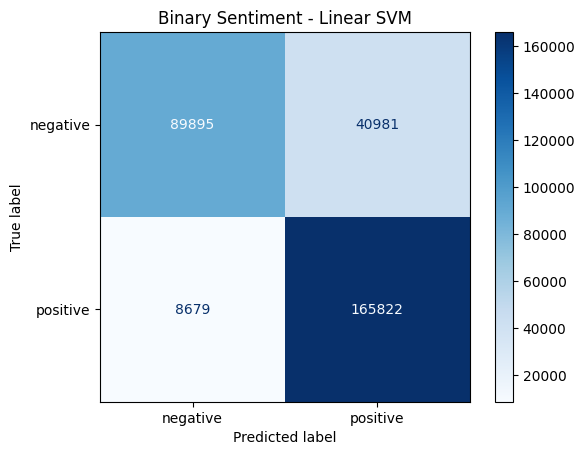

Model saved: ./saved_models/linear_svm_binary_text_ml.pkl


In [2]:
import os
import warnings
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    f1_score
)
from sklearn.utils import resample

warnings.filterwarnings("ignore")

FOLDER_PATH = r"/kaggle/input/datasets/yazanibrahimalghamdi/all-datasets-for-gp/All Datasets For GP"
RANDOM_STATE = 42
TEST_SIZE = 0.20
VALID_LABELS = ["negative", "positive"]


def normalize_sentiment_binary(label):
    if pd.isna(label):
        return None

    x = str(label).strip().lower()

    mapping = {
        "negative": "negative",
        "neg": "negative",
        "سلبي": "negative",

        "positive": "positive",
        "pos": "positive",
        "ايجابي": "positive",
        "إيجابي": "positive"
    }

    return mapping.get(x, None)


def stars_to_binary_sentiment(star):
    try:
        s = float(star)
    except:
        return None

    if s <= 2:
        return "negative"
    elif s >= 4:
        return "positive"
    else:
        return None


def read_file(file_path):
    ext = os.path.splitext(file_path)[1].lower()

    if ext == ".csv":
        for enc in ["utf-8-sig", "utf-8", "cp1256", "latin1"]:
            try:
                return pd.read_csv(file_path, encoding=enc)
            except:
                continue
        raise ValueError(f"Could not read CSV: {file_path}")

    elif ext in [".xlsx", ".xls"]:
        return pd.read_excel(file_path)

    return None


def infer_source(file_path):
    p = file_path.lower()

    if "tik tok" in p or "tiktok" in p:
        return "tiktok"
    elif "youtube" in p:
        return "youtube"
    elif "google maps" in p or "maps" in p:
        return "google_maps"
    else:
        return "unknown"


def should_use_file(file_path):
    p = file_path.lower()
    source = infer_source(file_path)

    if source in ["tiktok", "youtube"]:
        return ("cleaned" in p) and p.endswith((".xlsx", ".xls", ".csv"))

    if source == "google_maps":
        return p.endswith((".xlsx", ".xls", ".csv"))

    return False


def build_standard_df(df, file_path):
    source = infer_source(file_path)

    if "Text_ML" not in df.columns:
        return None

    temp = pd.DataFrame()
    temp["text"] = df["Text_ML"]

    if source in ["tiktok", "youtube"]:
        if "Sentiment" in df.columns:
            temp["sentiment"] = df["Sentiment"].apply(normalize_sentiment_binary)
        elif "sentiment" in df.columns:
            temp["sentiment"] = df["sentiment"].apply(normalize_sentiment_binary)
        elif "Stars" in df.columns:
            temp["sentiment"] = df["Stars"].apply(stars_to_binary_sentiment)
        elif "stars" in df.columns:
            temp["sentiment"] = df["stars"].apply(stars_to_binary_sentiment)
        else:
            return None

    elif source == "google_maps":
        if "stars" in df.columns:
            temp["sentiment"] = df["stars"].apply(stars_to_binary_sentiment)
        elif "Stars" in df.columns:
            temp["sentiment"] = df["Stars"].apply(stars_to_binary_sentiment)
        elif "Sentiment" in df.columns:
            temp["sentiment"] = df["Sentiment"].apply(normalize_sentiment_binary)
        elif "sentiment" in df.columns:
            temp["sentiment"] = df["sentiment"].apply(normalize_sentiment_binary)
        else:
            return None
    else:
        return None

    temp["source"] = source
    temp["file_name"] = os.path.basename(file_path)
    return temp


all_frames = []

for root, dirs, files in os.walk(FOLDER_PATH):
    for file in files:
        if not file.lower().endswith((".xlsx", ".xls", ".csv")):
            continue

        file_path = os.path.join(root, file)

        if not should_use_file(file_path):
            continue

        try:
            df = read_file(file_path)
            if df is None or df.empty:
                continue

            std_df = build_standard_df(df, file_path)
            if std_df is not None:
                all_frames.append(std_df)

        except:
            pass

data = pd.concat(all_frames, ignore_index=True)

# نحتفظ فقط بإيجابي/سلبي
data = data.dropna(subset=["text", "sentiment"])
data = data[data["sentiment"].isin(["negative", "positive"])]

print("Records used for binary classification:", len(data))
print(data["sentiment"].value_counts())

# =========================================
# Oversampling للـ negative
# =========================================
NEGATIVE_RATIO_TO_POSITIVE = 0.75

df_pos = data[data["sentiment"] == "positive"].copy()
df_neg = data[data["sentiment"] == "negative"].copy()

n_pos = len(df_pos)
target_neg = int(n_pos * NEGATIVE_RATIO_TO_POSITIVE)

if len(df_neg) < target_neg:
    df_neg_over = resample(
        df_neg,
        replace=True,
        n_samples=target_neg,
        random_state=RANDOM_STATE
    )
    data_balanced = pd.concat([df_pos, df_neg_over], ignore_index=True)
else:
    data_balanced = pd.concat([df_pos, df_neg], ignore_index=True)

data_balanced = data_balanced.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

print("\nAfter Oversampling:")
print(data_balanced["sentiment"].value_counts())
print("Balanced records:", len(data_balanced))

X = data_balanced["text"].astype(str)
y = data_balanced["sentiment"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

pipeline = Pipeline([
    ("features", FeatureUnion([
        ("word_tfidf", TfidfVectorizer(
            analyzer="word",
            ngram_range=(1, 2),
            max_features=25000,
            min_df=2,
            max_df=0.95,
            sublinear_tf=True
        )),
        ("char_tfidf", TfidfVectorizer(
            analyzer="char_wb",
            ngram_range=(3, 5),
            min_df=2,
            max_df=0.95,
            sublinear_tf=True
        ))
    ])),
    ("clf", LinearSVC(
        class_weight="balanced",
        random_state=RANDOM_STATE,
        C=1.0
    ))
])

print("Training binary Linear SVM ...")
pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)

acc = accuracy_score(y_test, y_pred)
f1_pos = f1_score(y_test, y_pred, average="binary", pos_label="positive")
f1_neg = f1_score(y_test, y_pred, average="binary", pos_label="negative")
f1_macro = f1_score(y_test, y_pred, average="macro")

print("\nAccuracy:", round(acc, 4))
print("Binary F1 (positive):", round(f1_pos, 4))
print("Binary F1 (negative):", round(f1_neg, 4))
print("Macro F1:", round(f1_macro, 4))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, labels=VALID_LABELS))

cm = confusion_matrix(y_test, y_pred, labels=VALID_LABELS)
print("Confusion Matrix:\n", cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=VALID_LABELS)
disp.plot(cmap="Blues", values_format="d")
plt.title("Binary Sentiment - Linear SVM")
plt.show()

# حفظ المودل
os.makedirs("./saved_models", exist_ok=True)
joblib.dump(pipeline, "./saved_models/linear_svm_binary_text_ml.pkl")
print("Model saved: ./saved_models/linear_svm_binary_text_ml.pkl")

Records used for binary classification: 1017499
sentiment
positive    872505
negative    144994
Name: count, dtype: int64

Before Oversampling (Train only):
sentiment
positive    698004
negative    115995
Name: count, dtype: int64

After Oversampling (Train only):
sentiment
positive    698004
negative    593303
Name: count, dtype: int64
Balanced train records: 1291307

Training binary Linear SVM ...

Accuracy: 0.893
Binary F1 (positive): 0.9376
Binary F1 (negative): 0.6253
Macro F1: 0.7814

Classification Report:

              precision    recall  f1-score   support

    negative       0.62      0.63      0.63     28999
    positive       0.94      0.94      0.94    174501

    accuracy                           0.89    203500
   macro avg       0.78      0.78      0.78    203500
weighted avg       0.89      0.89      0.89    203500

Confusion Matrix:
 [[ 18164  10835]
 [ 10937 163564]]


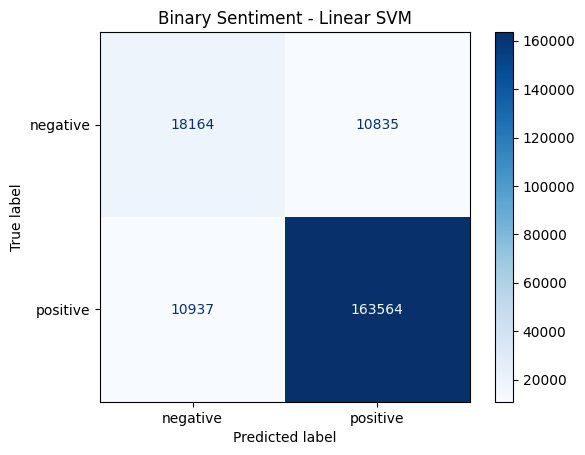

Model saved: ./saved_models/linear_svm_binary_text_ml_train_oversampled12.pkl


In [1]:
import os
import warnings
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    f1_score
)
from sklearn.utils import resample

warnings.filterwarnings("ignore")

FOLDER_PATH = r"/kaggle/input/datasets/yazanibrahimalghamdi/all-datasets-for-gp/All Datasets For GP"
RANDOM_STATE = 42
TEST_SIZE = 0.20
VALID_LABELS = ["negative", "positive"]

# نسبة تكبير negative مقارنة بعدد positive داخل التدريب فقط
NEGATIVE_RATIO_TO_POSITIVE = 0.85


def normalize_sentiment_binary(label):
    if pd.isna(label):
        return None

    x = str(label).strip().lower()

    mapping = {
        "negative": "negative",
        "neg": "negative",
        "سلبي": "negative",

        "positive": "positive",
        "pos": "positive",
        "ايجابي": "positive",
        "إيجابي": "positive"
    }

    return mapping.get(x, None)


def stars_to_binary_sentiment(star):
    try:
        s = float(star)
    except:
        return None

    if s <= 2:
        return "negative"
    elif s >= 4:
        return "positive"
    else:
        return None


def read_file(file_path):
    ext = os.path.splitext(file_path)[1].lower()

    if ext == ".csv":
        for enc in ["utf-8-sig", "utf-8", "cp1256", "latin1"]:
            try:
                return pd.read_csv(file_path, encoding=enc)
            except:
                continue
        raise ValueError(f"Could not read CSV: {file_path}")

    elif ext in [".xlsx", ".xls"]:
        return pd.read_excel(file_path)

    return None


def infer_source(file_path):
    p = file_path.lower()

    if "tik tok" in p or "tiktok" in p:
        return "tiktok"
    elif "youtube" in p:
        return "youtube"
    elif "google maps" in p or "maps" in p:
        return "google_maps"
    else:
        return "unknown"


def should_use_file(file_path):
    p = file_path.lower()
    source = infer_source(file_path)

    if source in ["tiktok", "youtube"]:
        return ("cleaned" in p) and p.endswith((".xlsx", ".xls", ".csv"))

    if source == "google_maps":
        return p.endswith((".xlsx", ".xls", ".csv"))

    return False


def build_standard_df(df, file_path):
    source = infer_source(file_path)

    if "Text_ML" not in df.columns:
        return None

    temp = pd.DataFrame()
    temp["text"] = df["Text_ML"]

    if source in ["tiktok", "youtube"]:
        if "Sentiment" in df.columns:
            temp["sentiment"] = df["Sentiment"].apply(normalize_sentiment_binary)
        elif "sentiment" in df.columns:
            temp["sentiment"] = df["sentiment"].apply(normalize_sentiment_binary)
        elif "Stars" in df.columns:
            temp["sentiment"] = df["Stars"].apply(stars_to_binary_sentiment)
        elif "stars" in df.columns:
            temp["sentiment"] = df["stars"].apply(stars_to_binary_sentiment)
        else:
            return None

    elif source == "google_maps":
        if "stars" in df.columns:
            temp["sentiment"] = df["stars"].apply(stars_to_binary_sentiment)
        elif "Stars" in df.columns:
            temp["sentiment"] = df["Stars"].apply(stars_to_binary_sentiment)
        elif "Sentiment" in df.columns:
            temp["sentiment"] = df["Sentiment"].apply(normalize_sentiment_binary)
        elif "sentiment" in df.columns:
            temp["sentiment"] = df["sentiment"].apply(normalize_sentiment_binary)
        else:
            return None
    else:
        return None

    temp["source"] = source
    temp["file_name"] = os.path.basename(file_path)
    return temp


# =========================================
# قراءة وتجميع الملفات
# =========================================
all_frames = []

for root, dirs, files in os.walk(FOLDER_PATH):
    for file in files:
        if not file.lower().endswith((".xlsx", ".xls", ".csv")):
            continue

        file_path = os.path.join(root, file)

        if not should_use_file(file_path):
            continue

        try:
            df = read_file(file_path)
            if df is None or df.empty:
                continue

            std_df = build_standard_df(df, file_path)
            if std_df is not None:
                all_frames.append(std_df)

        except Exception:
            pass

data = pd.concat(all_frames, ignore_index=True)

# =========================================
# تنظيف نهائي
# =========================================
data = data.dropna(subset=["text", "sentiment"])
data["text"] = data["text"].astype(str).str.strip()
data = data[data["text"] != ""]
data = data[data["sentiment"].isin(["negative", "positive"])]

print("Records used for binary classification:", len(data))
print(data["sentiment"].value_counts())

# =========================================
# Split أولاً
# =========================================
X = data["text"].astype(str)
y = data["sentiment"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

print("\nBefore Oversampling (Train only):")
print(y_train.value_counts())

# =========================================
# Oversampling على TRAIN فقط
# =========================================
train_df = pd.DataFrame({
    "text": X_train.values,
    "sentiment": y_train.values
})

df_pos = train_df[train_df["sentiment"] == "positive"].copy()
df_neg = train_df[train_df["sentiment"] == "negative"].copy()

target_neg = int(len(df_pos) * NEGATIVE_RATIO_TO_POSITIVE)

if len(df_neg) < target_neg:
    df_neg_over = resample(
        df_neg,
        replace=True,
        n_samples=target_neg,
        random_state=RANDOM_STATE
    )
else:
    df_neg_over = df_neg.copy()

train_balanced = pd.concat([df_pos, df_neg_over], ignore_index=True)
train_balanced = train_balanced.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

X_train = train_balanced["text"]
y_train = train_balanced["sentiment"]

print("\nAfter Oversampling (Train only):")
print(y_train.value_counts())
print("Balanced train records:", len(train_balanced))

# =========================================
# Pipeline
# =========================================
pipeline = Pipeline([
    ("features", FeatureUnion([
        ("word_tfidf", TfidfVectorizer(
            analyzer="word",
            ngram_range=(1, 2),
            max_features=25000,
            min_df=2,
            max_df=0.95,
            sublinear_tf=True
        )),
        ("char_tfidf", TfidfVectorizer(
            analyzer="char_wb",
            ngram_range=(3, 5),
            min_df=2,
            max_df=0.95,
            sublinear_tf=True
        ))
    ])),
    ("clf", LinearSVC(
        class_weight={"negative": 2, "positive": 1},
        random_state=RANDOM_STATE,
        C=1.0
    ))
])

# =========================================
# التدريب
# =========================================
print("\nTraining binary Linear SVM ...")
pipeline.fit(X_train, y_train)

# =========================================
# التنبؤ
# =========================================
y_pred = pipeline.predict(X_test)

# =========================================
# التقييم
# =========================================
acc = accuracy_score(y_test, y_pred)
f1_pos = f1_score(y_test, y_pred, average="binary", pos_label="positive")
f1_neg = f1_score(y_test, y_pred, average="binary", pos_label="negative")
f1_macro = f1_score(y_test, y_pred, average="macro")

print("\nAccuracy:", round(acc, 4))
print("Binary F1 (positive):", round(f1_pos, 4))
print("Binary F1 (negative):", round(f1_neg, 4))
print("Macro F1:", round(f1_macro, 4))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, labels=VALID_LABELS))

cm = confusion_matrix(y_test, y_pred, labels=VALID_LABELS)
print("Confusion Matrix:\n", cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=VALID_LABELS)
disp.plot(cmap="Blues", values_format="d")
plt.title("Binary Sentiment - Linear SVM")
plt.show()

# =========================================
# حفظ المودل
# =========================================
os.makedirs("./saved_models", exist_ok=True)
joblib.dump(pipeline, "./saved_models/linear_svm_binary_text_ml_train_oversampled12.pkl")
print("Model saved: ./saved_models/linear_svm_binary_text_ml_train_oversampled12.pkl")

In [ ]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    f1_score,
    make_scorer
)

warnings.filterwarnings("ignore")

FOLDER_PATH = r"/kaggle/input/datasets/yazanibrahimalghamdi/all-datasets-for-gp/All Datasets For GP"
RANDOM_STATE = 42
VALID_LABELS = ["negative", "positive"]


def normalize_sentiment_binary(label):
    if pd.isna(label):
        return None

    x = str(label).strip().lower()

    mapping = {
        "negative": "negative",
        "neg": "negative",
        "سلبي": "negative",

        "positive": "positive",
        "pos": "positive",
        "ايجابي": "positive",
        "إيجابي": "positive"
    }

    return mapping.get(x, None)


def stars_to_binary_sentiment(star):
    try:
        s = float(star)
    except:
        return None

    if s <= 2:
        return "negative"
    elif s >= 4:
        return "positive"
    else:
        return None


def read_file(file_path):
    ext = os.path.splitext(file_path)[1].lower()

    if ext == ".csv":
        for enc in ["utf-8-sig", "utf-8", "cp1256", "latin1"]:
            try:
                return pd.read_csv(file_path, encoding=enc)
            except:
                continue
        raise ValueError(f"Could not read CSV: {file_path}")

    elif ext in [".xlsx", ".xls"]:
        return pd.read_excel(file_path)

    return None


def infer_source(file_path):
    p = file_path.lower()

    if "tik tok" in p or "tiktok" in p:
        return "tiktok"
    elif "youtube" in p:
        return "youtube"
    elif "google maps" in p or "maps" in p:
        return "google_maps"
    else:
        return "unknown"


def should_use_file(file_path):
    p = file_path.lower()
    source = infer_source(file_path)

    if source in ["tiktok", "youtube"]:
        return ("cleaned" in p) and p.endswith((".xlsx", ".xls", ".csv"))

    if source == "google_maps":
        return p.endswith((".xlsx", ".xls", ".csv"))

    return False


def build_standard_df(df, file_path):
    source = infer_source(file_path)

    if "Text_ML" not in df.columns:
        return None

    temp = pd.DataFrame()
    temp["text"] = df["Text_ML"].astype(str)

    # ملاحظة مهمة:
    # إضافة source كتوكن داخل النص لا تغيّر الداتا نفسها،
    # لكنها تعطي المودل إشارة من أي منصة جاء التعليق.
    temp["text"] = "__src__" + source + " " + temp["text"]

    if source in ["tiktok", "youtube"]:
        if "Sentiment" in df.columns:
            temp["sentiment"] = df["Sentiment"].apply(normalize_sentiment_binary)
        elif "sentiment" in df.columns:
            temp["sentiment"] = df["sentiment"].apply(normalize_sentiment_binary)
        elif "Stars" in df.columns:
            temp["sentiment"] = df["Stars"].apply(stars_to_binary_sentiment)
        elif "stars" in df.columns:
            temp["sentiment"] = df["stars"].apply(stars_to_binary_sentiment)
        else:
            return None

    elif source == "google_maps":
        if "stars" in df.columns:
            temp["sentiment"] = df["stars"].apply(stars_to_binary_sentiment)
        elif "Stars" in df.columns:
            temp["sentiment"] = df["Stars"].apply(stars_to_binary_sentiment)
        elif "Sentiment" in df.columns:
            temp["sentiment"] = df["Sentiment"].apply(normalize_sentiment_binary)
        elif "sentiment" in df.columns:
            temp["sentiment"] = df["sentiment"].apply(normalize_sentiment_binary)
        else:
            return None
    else:
        return None

    temp["source"] = source
    temp["file_name"] = os.path.basename(file_path)
    return temp


# =========================================================
# 1) قراءة وتجميع البيانات
# =========================================================
all_frames = []

for root, dirs, files in os.walk(FOLDER_PATH):
    for file in files:
        if not file.lower().endswith((".xlsx", ".xls", ".csv")):
            continue

        file_path = os.path.join(root, file)

        if not should_use_file(file_path):
            continue

        try:
            df = read_file(file_path)
            if df is None or df.empty:
                continue

            std_df = build_standard_df(df, file_path)
            if std_df is not None:
                all_frames.append(std_df)

        except Exception:
            pass

data = pd.concat(all_frames, ignore_index=True)

data = data.dropna(subset=["text", "sentiment"])
data["text"] = data["text"].astype(str).str.strip()
data = data[data["text"] != ""]
data = data[data["sentiment"].isin(["negative", "positive"])]

print("Records used for binary classification:", len(data))
print(data["sentiment"].value_counts())

X = data["text"].astype(str)
y = data["sentiment"]

# =========================================================
# 2) تقسيم Train / Valid / Test
# =========================================================
# 80% train_temp / 20% test
X_train_temp, X_test, y_train_temp, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

# من الـ 80% ناخذ 20% validation => 16% من الكل
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_temp, y_train_temp,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_train_temp
)

print("\nTrain size:", len(X_train))
print("Valid size:", len(X_valid))
print("Test size :", len(X_test))

# =========================================================
# 3) Pipeline
# =========================================================
pipeline = Pipeline([
    ("features", FeatureUnion([
        ("word_tfidf", TfidfVectorizer()),
        ("char_tfidf", TfidfVectorizer(analyzer="char_wb"))
    ])),
    ("clf", LinearSVC(random_state=RANDOM_STATE, max_iter=5000))
])

# =========================================================
# 4) Scorer يركز على الـ negative
# =========================================================
negative_f1_scorer = make_scorer(
    f1_score,
    pos_label="negative",
    average="binary"
)

# =========================================================
# 5) بحث عشوائي خفيف
# =========================================================
param_dist = {
    "features__word_tfidf__ngram_range": [(1, 1), (1, 2), (1, 3)],
    "features__word_tfidf__max_features": [20000, 30000, 40000],
    "features__word_tfidf__min_df": [2, 3, 5],
    "features__word_tfidf__max_df": [0.90, 0.95, 0.98],
    "features__word_tfidf__sublinear_tf": [True],
    "features__word_tfidf__binary": [False, True],

    "features__char_tfidf__ngram_range": [(3, 5), (3, 6), (4, 6)],
    "features__char_tfidf__min_df": [2, 3],
    "features__char_tfidf__max_df": [0.95, 0.98],
    "features__char_tfidf__sublinear_tf": [True],
    "features__char_tfidf__binary": [False, True],

    "clf__C": [0.25, 0.5, 1.0, 1.5, 2.0, 3.0],
    "clf__loss": ["hinge", "squared_hinge"],
    "clf__class_weight": [
        None,
        "balanced",
        {"negative": 1.5, "positive": 1},
        {"negative": 2, "positive": 1},
        {"negative": 3, "positive": 1}
    ]
}

search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_dist,
    n_iter=18,                 # خفيف نسبيًا
    scoring={
        "f1_negative": negative_f1_scorer,
        "f1_macro": "f1_macro",
        "accuracy": "accuracy"
    },
    refit="f1_negative",       # أهم شيء عندنا
    cv=3,
    verbose=2,
    n_jobs=-1,
    random_state=RANDOM_STATE
)

print("\nRunning RandomizedSearchCV ...")
search.fit(X_train, y_train)

best_model = search.best_estimator_
print("\nBest Params:")
print(search.best_params_)
print("Best CV f1_negative:", round(search.best_score_, 4))

# =========================================================
# 6) Threshold tuning على validation
# =========================================================
# في LinearSVC: score > threshold => positive ، وإلا negative
valid_scores = best_model.decision_function(X_valid)

thresholds = np.arange(-1.50, 1.51, 0.10)

best_threshold = 0.0
best_valid_f1_neg = -1

for thr in thresholds:
    y_valid_pred_thr = np.where(valid_scores >= thr, "positive", "negative")
    score = f1_score(y_valid, y_valid_pred_thr, pos_label="negative", average="binary")

    if score > best_valid_f1_neg:
        best_valid_f1_neg = score
        best_threshold = thr

print("\nBest threshold on validation:", round(best_threshold, 2))
print("Best validation F1 (negative):", round(best_valid_f1_neg, 4))

# =========================================================
# 7) تقييم نهائي على test
# =========================================================
test_scores = best_model.decision_function(X_test)
y_test_pred = np.where(test_scores >= best_threshold, "positive", "negative")

acc = accuracy_score(y_test, y_test_pred)
f1_pos = f1_score(y_test, y_test_pred, average="binary", pos_label="positive")
f1_neg = f1_score(y_test, y_test_pred, average="binary", pos_label="negative")
f1_macro = f1_score(y_test, y_test_pred, average="macro")

print("\nFinal Test Results")
print("Accuracy:", round(acc, 4))
print("Binary F1 (positive):", round(f1_pos, 4))
print("Binary F1 (negative):", round(f1_neg, 4))
print("Macro F1:", round(f1_macro, 4))

print("\nClassification Report:\n")
print(classification_report(y_test, y_test_pred, labels=VALID_LABELS))

cm = confusion_matrix(y_test, y_test_pred, labels=VALID_LABELS)
print("Confusion Matrix:\n", cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=VALID_LABELS)
disp.plot(cmap="Blues", values_format="d")
plt.title("Binary Sentiment - Optimized LinearSVC")
plt.show()

# =========================================================
# 8) الحفظ
# =========================================================
os.makedirs("./saved_models", exist_ok=True)

joblib.dump(
    {
        "model": best_model,
        "threshold": best_threshold,
        "best_params": search.best_params_
    },
    "./saved_models/linear_svm_binary_optimized.pkl"
)

print("\nSaved: ./saved_models/linear_svm_binary_optimized.pkl")

Records used for binary classification: 1017499
sentiment
positive    872505
negative    144994
Name: count, dtype: int64

Train size: 651199
Valid size: 162800
Test size : 203500

Running RandomizedSearchCV ...
Fitting 3 folds for each of 18 candidates, totalling 54 fits


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  w

[CV] END clf__C=1.5, clf__class_weight=None, clf__loss=squared_hinge, features__char_tfidf__binary=False, features__char_tfidf__max_df=0.98, features__char_tfidf__min_df=2, features__char_tfidf__ngram_range=(4, 6), features__char_tfidf__sublinear_tf=True, features__word_tfidf__binary=True, features__word_tfidf__max_df=0.95, features__word_tfidf__max_features=40000, features__word_tfidf__min_df=5, features__word_tfidf__ngram_range=(1, 3), features__word_tfidf__sublinear_tf=True; total time=31.4min
[CV] END clf__C=1.5, clf__class_weight={'negative': 2, 'positive': 1}, clf__loss=squared_hinge, features__char_tfidf__binary=True, features__char_tfidf__max_df=0.98, features__char_tfidf__min_df=2, features__char_tfidf__ngram_range=(3, 5), features__char_tfidf__sublinear_tf=True, features__word_tfidf__binary=True, features__word_tfidf__max_df=0.9, features__word_tfidf__max_features=30000, features__word_tfidf__min_df=3, features__word_tfidf__ngram_range=(1, 3), features__word_tfidf__sublinear_